# Donchian lookback sweep — score & Sharpe

Backtests the Donchian breakout on ALGO over the **first 250 days** for a range of lookbacks, then scatters lookback vs competition score and lookback vs annualised Sharpe.

All lookbacks are scored over the **same fixed window** (day `max(LOOKBACKS)+1` onward) so points are comparable regardless of their own warm-up period — same approach as `param_sweep.py` in the other strategy folders.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# works whether the notebook runs with cwd = repo root or this folder
ROOT = Path.cwd() if (Path.cwd() / "prices.txt").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "algo_donchian"))
from donchian import DonchianStrategy

prcAll = pd.read_csv(ROOT / "prices.txt", sep=r"\s+", header=0, index_col=None).values.T
nInst, nt = prcAll.shape

N_DAYS = 250
prcHist = prcAll[:, :N_DAYS]

LOOKBACKS = list(range(5, 105, 5))
START_DAY = max(LOOKBACKS) + 1  # same scoring window for every lookback
print(f"backtesting first {N_DAYS} days; scoring days {START_DAY + 1}..{N_DAYS} "
      f"({N_DAYS - START_DAY} scored days per config)")

backtesting first 250 days; scoring days 102..250 (149 scored days per config)


In [2]:
def score(mu, sigma, param=1.0):
    if mu <= 0 or sigma < 1e-10:
        return mu
    sr = np.sqrt(250) * mu / sigma
    return mu * sr**2 / (sr**2 + param**2)


def backtest(strategy, prcHist, startDay):
    """eval.py's PnL loop; PnL scored for days startDay+1 .. nt."""
    nInst, nt = prcHist.shape
    commRate = np.full(nInst, 0.0001)
    commRate[0] = 0.00002
    dlrPosLimit = np.full(nInst, 10_000.0)
    dlrPosLimit[0] = 100_000.0

    cash, value, comm = 0.0, 0.0, 0.0
    curPos = np.zeros(nInst)
    todayPLL = []
    entries = 0
    prevDir = 0

    for t in range(startDay, nt + 1):
        prcSoFar = prcHist[:, :t]
        curPrices = prcSoFar[:, -1]
        if t < nt:
            newPos = strategy.step(prcSoFar)
            if prevDir == 0 and strategy.tradeDir != 0:
                entries += 1
            prevDir = strategy.tradeDir
            posLimits = (dlrPosLimit / curPrices).astype(int)
            newPos = np.clip(newPos, -posLimits, posLimits).astype(int)
        else:
            newPos = np.array(curPos)

        deltaPos = newPos - curPos
        cash -= curPrices.dot(deltaPos) + comm
        dvolumes = curPrices * np.abs(deltaPos)
        comm = np.sum(dvolumes * commRate)
        curPos = np.array(newPos)
        todayPL = cash + curPos.dot(curPrices) - value
        value = cash + curPos.dot(curPrices)
        if t > startDay:
            todayPLL.append(todayPL)

    pll = np.array(todayPLL)
    mu, sd = pll.mean(), pll.std()
    sharpe = np.sqrt(250) * mu / sd if sd > 0 else 0.0
    return {"meanPL": mu, "stdPL": sd, "sharpe": sharpe,
            "score": score(mu, sd), "entries": entries}

In [3]:
rows = []
for lb in LOOKBACKS:
    r = backtest(DonchianStrategy(lookback=lb), prcHist, START_DAY)
    rows.append({"lookback": lb, **r})
    print(f"LOOKBACK={lb:3d}  score={r['score']:8.2f}  sharpe={r['sharpe']:5.2f}  "
          f"meanPL={r['meanPL']:8.2f}  entries={r['entries']:2d}")

results = pd.DataFrame(rows)
results.sort_values("score", ascending=False).head(5)

LOOKBACK=  5  score=  -53.13  sharpe=-0.97  meanPL=  -53.13  entries=26
LOOKBACK= 10  score=   31.20  sharpe= 1.04  meanPL=   59.90  entries=11
LOOKBACK= 15  score=    2.73  sharpe= 0.39  meanPL=   21.12  entries= 9
LOOKBACK= 20  score=  -32.78  sharpe=-0.62  meanPL=  -32.78  entries= 8
LOOKBACK= 25  score=  -15.67  sharpe=-0.32  meanPL=  -15.67  entries= 6
LOOKBACK= 30  score=  -22.21  sharpe=-0.47  meanPL=  -22.21  entries= 5
LOOKBACK= 35  score=   -9.63  sharpe=-0.24  meanPL=   -9.63  entries= 4
LOOKBACK= 40  score=  -10.60  sharpe=-0.26  meanPL=  -10.60  entries= 4
LOOKBACK= 45  score=  -21.83  sharpe=-0.54  meanPL=  -21.83  entries= 4
LOOKBACK= 50  score=   -4.29  sharpe=-0.09  meanPL=   -4.29  entries= 4
LOOKBACK= 55  score=  -23.68  sharpe=-0.49  meanPL=  -23.68  entries= 4
LOOKBACK= 60  score=  -27.57  sharpe=-0.57  meanPL=  -27.57  entries= 4
LOOKBACK= 65  score=  -22.14  sharpe=-0.46  meanPL=  -22.14  entries= 3
LOOKBACK= 70  score=  -24.02  sharpe=-0.49  meanPL=  -24.02  ent

,lookback,meanPL,stdPL,sharpe,score,entries
1,10,59.899316,908.405385,1.042587,31.197979,11
2,15,21.120322,865.877826,0.385668,2.734681,9
9,50,-4.293181,750.550942,-0.090442,-4.293181,4
6,35,-9.633962,639.464051,-0.238209,-9.633962,4
7,40,-10.601375,636.338891,-0.263417,-10.601375,4


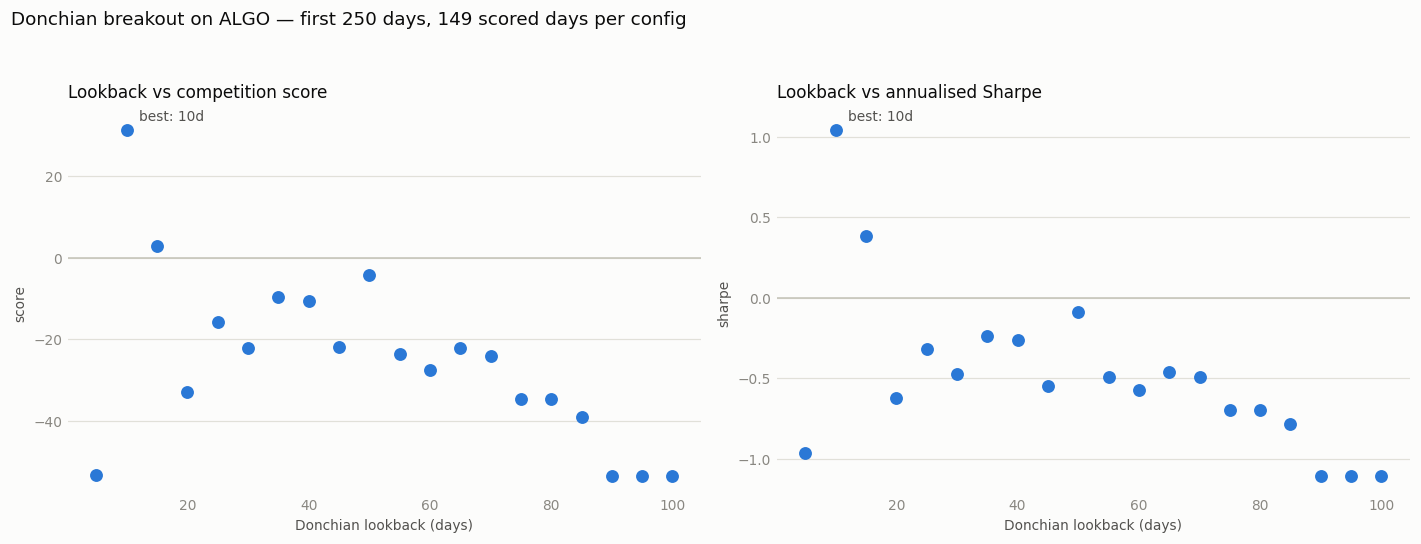

In [4]:
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
BLUE = "#2a78d6"

fig, (axs, axh) = plt.subplots(1, 2, figsize=(13, 5), dpi=110)
fig.patch.set_facecolor(SURFACE)

for ax, col, title in [
    (axs, "score", "Lookback vs competition score"),
    (axh, "sharpe", "Lookback vs annualised Sharpe"),
]:
    ax.set_facecolor(SURFACE)
    ax.axhline(0, color=BASELINE, linewidth=1)
    ax.scatter(results["lookback"], results[col], s=55, color=BLUE, zorder=3)
    best = results.loc[results[col].idxmax()]
    ax.annotate(f"best: {int(best['lookback'])}d",
                xy=(best["lookback"], best[col]), xytext=(8, 6),
                textcoords="offset points", color=INK2, fontsize=9)
    ax.set_title(title, color=INK, fontsize=11, loc="left", pad=10)
    ax.set_xlabel("Donchian lookback (days)", color=INK2, fontsize=9)
    ax.set_ylabel(col, color=INK2, fontsize=9)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, length=0, labelsize=9)
    for s in ax.spines.values():
        s.set_visible(False)

fig.suptitle(f"Donchian breakout on ALGO — first {N_DAYS} days, "
             f"{N_DAYS - START_DAY} scored days per config",
             color=INK, fontsize=12, x=0.01, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()